# Exploring Residual Power Spectra and Fourier Phase Information

Powerspectra discard phase information, and thus multiple realisations of a field can have identical powerspectra. The question is whether the powerspectra of the residuals between fields with identical PS can tell us anything about the difference in their morphology

We consider three increasingly general examples:

1. A translated point distribution.
2. Two point distributions with identical autocorrelations.
3. Two independent Gaussian random field realisations drawn from the same ensemble.

For each example we compare the fields themselves, their power spectra, the residual field, and the corresponding Fourier phase differences.

In [1]:
import numpy as np
import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as LSC

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.9, 256)))
prd.set_under("white")

In [2]:
def power_spectrum_1d(field, nbins=32, dx=1.0):
    """
    Compute the azimuthally averaged 1D power spectrum of a 2D field.

    Parameters
    ----------
    field : np.ndarray
        2D input field.
    nbins : int
        Number of radial Fourier bins.
    dx : float
        Pixel spacing.

    Returns
    -------
    k_centres : np.ndarray
        Bin centres in Fourier wavenumber units.
    ps_1d : np.ndarray
        Radially averaged power spectrum.
    """
    field = np.asarray(field)

    if field.ndim != 2:
        raise ValueError("field must be a 2D array")

    ny, nx = field.shape

    ft = np.fft.fft2(field)
    ps_2d = np.abs(ft) ** 2

    kx = np.fft.fftfreq(nx, d=dx)
    ky = np.fft.fftfreq(ny, d=dx)

    kx_grid, ky_grid = np.meshgrid(kx, ky)
    k_radius = np.sqrt(kx_grid**2 + ky_grid**2)

    k_flat = k_radius.ravel()
    ps_flat = ps_2d.ravel()

    bin_edges = np.linspace(0, k_flat.max(), nbins + 1)
    bin_indices = np.digitize(k_flat, bin_edges) - 1

    ps_1d = np.full(nbins, np.nan)
    k_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    for i in range(nbins):
        mask = bin_indices == i
        if np.any(mask):
            ps_1d[i] = ps_flat[mask].mean()

    return k_centres, ps_1d

## Let's start with a very simple case

Power spectrum is phase agnostic. This means that for a simple binary field, translation of all points should preserve the PS. But what about the PS of the residuals?

Let's generate a 256x256 grid, and make a circle of pixels of 64 pixels on it. This will be out first field. We can translate the circle to form our second field. In principle the fields should have identical PS.

In [3]:
def circle_points(centre, radius, npix):
    """
    Generate integer pixel coordinates along a circle.

    Parameters
    ----------
    centre : tuple[float, float]
        Circle centre (x, y).
    radius : float
        Circle radius in pixels.
    npix : int
        Number of points around the circumference.

    Returns
    -------
    xpix : np.ndarray
        Integer x coordinates.
    ypix : np.ndarray
        Integer y coordinates.
    """
    cx, cy = centre

    theta = np.linspace(0, 2 * np.pi, npix, endpoint=False)

    xpix = np.rint(cx + radius * np.cos(theta)).astype(int)
    ypix = np.rint(cy + radius * np.sin(theta)).astype(int)

    return xpix, ypix

In [4]:
x1, y1 = circle_points(centre=(128, 128), radius=64, npix=128)
x2, y2 = circle_points(centre=(128, 184), radius=64, npix=128)

In [5]:
field1 = np.zeros((256, 256), dtype=float)
field1[y1, x1] = 1.0

field2 = np.zeros((256, 256), dtype=float)
field2[y2, x2] = 1.0

residual = field1 - field2

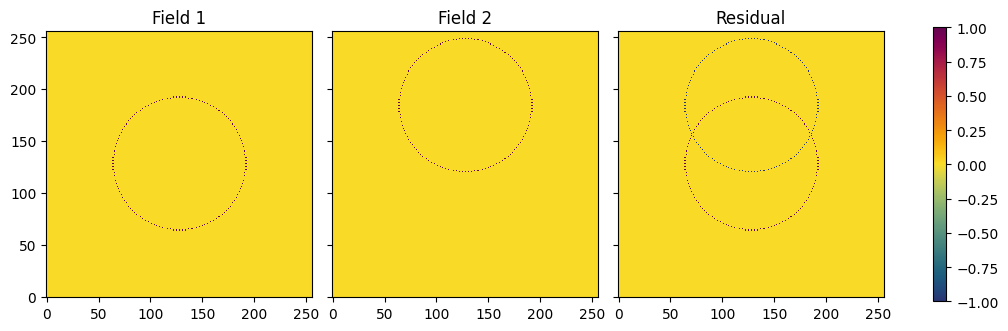

In [6]:
f_list = [field1, field2, residual]

vmin = min(f.min() for f in f_list)
vmax = max(f.max() for f in f_list)

fig, axs = plt.subplots(
    1, 3,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, ps, title in zip(axs, f_list, ["Field 1", "Field 2", "Residual"]):
    im = ax.imshow(
        ps,
        origin="lower",
        cmap=prd,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
    )
    ax.set_title(title)

cbar = fig.colorbar(
    im,
    ax=axs,
    shrink=0.7,
)

plt.show()

In [7]:
k1, p1 = power_spectrum_1d(field1, nbins=64)
k2, p2 = power_spectrum_1d(field2, nbins=64)
kr, pr = power_spectrum_1d(residual, nbins=64)

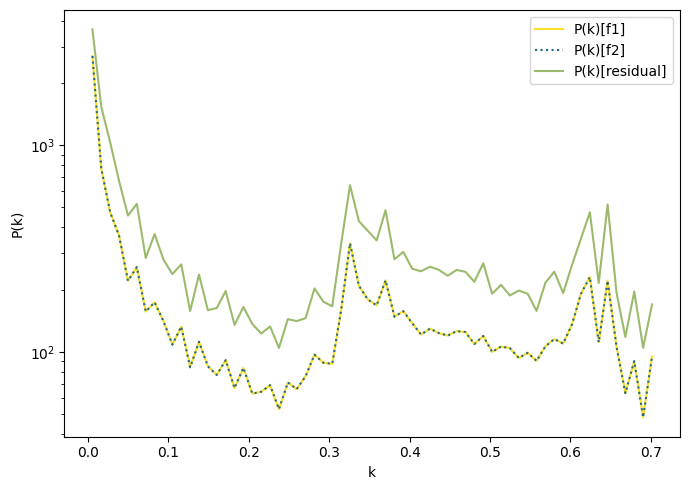

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(k1, p1, color=cmr.pride(0.5), label="P(k)[f1]")
ax.semilogy(k2, p2, color=cmr.pride(0.2), ls=":", label="P(k)[f2]")
ax.semilogy(kr, pr, color=cmr.pride(0.4), label="P(k)[residual]")

plt.legend()

ax.set_ylabel("P(k)")
ax.set_xlabel("k")

plt.tight_layout()
plt.show()

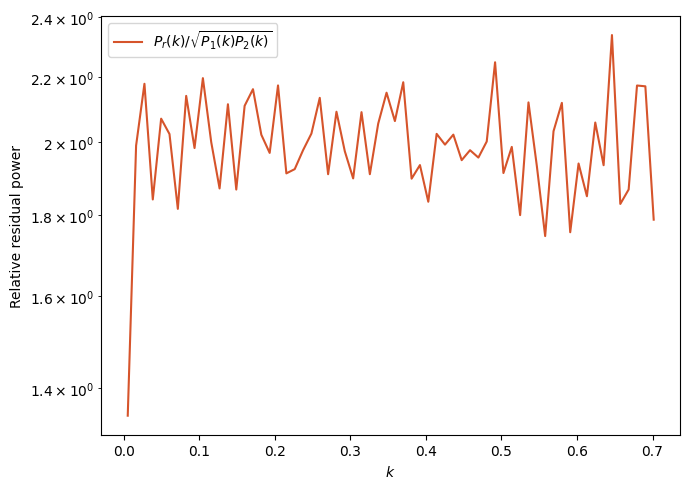

In [9]:
eps = 1e-12

fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(
    kr,
    pr / (np.sqrt(p1 * p2)),
    color=cmr.pride(0.7),
    label=r"$P_r(k)/\sqrt{P_1(k)P_2(k)}$",
)

ax.legend()

ax.set_ylabel("Relative residual power")
ax.set_xlabel(r"$k$")

plt.tight_layout()
plt.show()

## Residual Power Spectra and Phase Information

The goal is to investigate whether two fields can have identical power spectra while still being different in real space.

Suppose we construct two fields, $f_1(\mathbf{x})$ and $f_2(\mathbf{x})$, with identical power spectra. We then form the residual

$$
r(\mathbf{x}) = f_1(\mathbf{x}) - f_2(\mathbf{x}),
$$

and compute its power spectrum,

$$
P_r(\mathbf{k}) = |\tilde r(\mathbf{k})|^2.
$$

If the residual power spectrum is non-zero, this immediately demonstrates that the two fields are not identical, despite having the same individual power spectra.

### Fourier Representation

Write the Fourier transforms of the two fields as

$$
\tilde f_1(\mathbf{k})
=
A(\mathbf{k})\,e^{i\phi_1(\mathbf{k})},
$$

and

$$
\tilde f_2(\mathbf{k})
=
A(\mathbf{k})\,e^{i\phi_2(\mathbf{k})},
$$

where the amplitudes are identical because the power spectra are identical:

$$
P(\mathbf{k})
=
|\tilde f_1(\mathbf{k})|^2
=
|\tilde f_2(\mathbf{k})|^2
=
A^2(\mathbf{k}).
$$

The residual in Fourier space is therefore

$$
\tilde r(\mathbf{k})
=
A(\mathbf{k})
\left[
e^{i\phi_1(\mathbf{k})}
-
e^{i\phi_2(\mathbf{k})}
\right].
$$

Its power spectrum becomes

$$
P_r(\mathbf{k})
=
A^2(\mathbf{k})
\left|
e^{i\phi_1}
-
e^{i\phi_2}
\right|^2.
$$

Using the identity

$$
|e^{ia}-e^{ib}|^2
=
2-2\cos(a-b),
$$

we obtain

$$
P_r(\mathbf{k})
=
2P(\mathbf{k})
\left[
1-\cos\bigl(\Delta\phi(\mathbf{k})\bigr)
\right],
$$

where

$$
\Delta\phi(\mathbf{k})
=
\phi_1(\mathbf{k})
-
\phi_2(\mathbf{k}).
$$

Using

$$
1-\cos\theta
=
2\sin^2\left(\frac{\theta}{2}\right),
$$

gives

$$
P_r(\mathbf{k})
=
4P(\mathbf{k})
\sin^2\!\left(
\frac{\Delta\phi(\mathbf{k})}{2}
\right).
$$

This result shows that the residual power spectrum depends entirely on the phase differences between the two fields. The original power spectra are blind to phase information, whereas the residual power spectrum is explicitly sensitive to it.

### Special Case: A Pure Translation

In this example, the second field is simply a translated version of the first:

$$
f_2(\mathbf{x})
=
f_1(\mathbf{x}-\Delta\mathbf{x}).
$$

The Fourier shift theorem gives

$$
\tilde f_2(\mathbf{k})
=
\tilde f_1(\mathbf{k})
e^{-i\mathbf{k}\cdot\Delta\mathbf{x}}.
$$

The phase difference is therefore

$$
\Delta\phi(\mathbf{k})
=
\mathbf{k}\cdot\Delta\mathbf{x},
$$

and the residual power spectrum becomes

$$
P_r(\mathbf{k})
=
4P(\mathbf{k})
\sin^2\!\left(
\frac{\mathbf{k}\cdot\Delta\mathbf{x}}{2}
\right).
$$

Consequently,

$$
\frac{P_r(\mathbf{k})}{P(\mathbf{k})}
=
4\sin^2\!\left(
\frac{\mathbf{k}\cdot\Delta\mathbf{x}}{2}
\right).
$$

### Why Does the Spherically Averaged Ratio Approach 2?

The expression above depends on the direction of $\mathbf{k}$ through the dot product $\mathbf{k}\cdot\Delta\mathbf{x}$.

When computing a one-dimensional power spectrum, we average over all Fourier modes with the same magnitude $k = |\mathbf{k}|$. This angular averaging samples many values of the phase difference, causing

$$
\sin^2\!\left(
\frac{\mathbf{k}\cdot\Delta\mathbf{x}}{2}
\right)
$$

to oscillate between 0 and 1.

The average value of $\sin^2$ over a complete cycle is

$$
\left\langle \sin^2 \theta \right\rangle
=
\frac{1}{2}.
$$

Therefore, after spherical averaging,

$$
\left\langle
\frac{P_r(k)}{P(k)}
\right\rangle
=
4
\left\langle
\sin^2 \theta
\right\rangle
=
4\times\frac{1}{2}
=
2.
$$

This explains the numerical result observed above: although the two translated fields have identical power spectra, the residual power spectrum contains approximately twice as much power as either individual field after angular averaging.

This provides a simple demonstration that two fields can have identical power spectra while still being distinct in real space. The missing information is encoded in the Fourier phases, which are discarded when forming the power spectrum.

## Maybe a 2D PS tells us more?

The math above says that we're losing information is the sperical averaging. Perhaps we should look at the 2D PS? We should at least see the phase ramp from translation?

In [10]:
def power_spectrum_2d(field, shift=True):
    ft = np.fft.fft2(field)
    ps = np.abs(ft) ** 2

    if shift:
        ps = np.fft.fftshift(ps)

    return ps

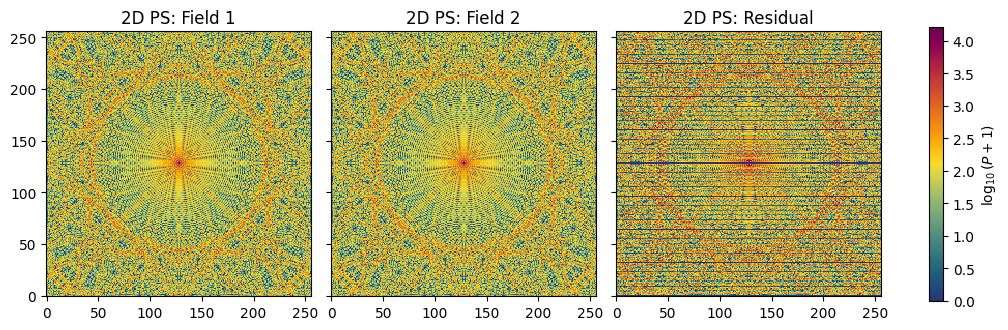

In [11]:
ps1_2d = power_spectrum_2d(field1)
ps2_2d = power_spectrum_2d(field2)
psr_2d = power_spectrum_2d(residual)

ps_list = [
    np.log10(ps1_2d + 1),
    np.log10(ps2_2d + 1),
    np.log10(psr_2d + 1),
]

vmin = min(ps.min() for ps in ps_list)
vmax = max(ps.max() for ps in ps_list)

fig, axs = plt.subplots(
    1, 3,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, ps, title in zip(axs, ps_list, ["2D PS: Field 1", "2D PS: Field 2", "2D PS: Residual"]):
    im = ax.imshow(
        ps,
        origin="lower",
        cmap=prd,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
    )
    ax.set_title(title)

cbar = fig.colorbar(
    im,
    ax=axs,
    shrink=0.7,
    label=r"$\log_{10}(P+1)$",
)

plt.show()

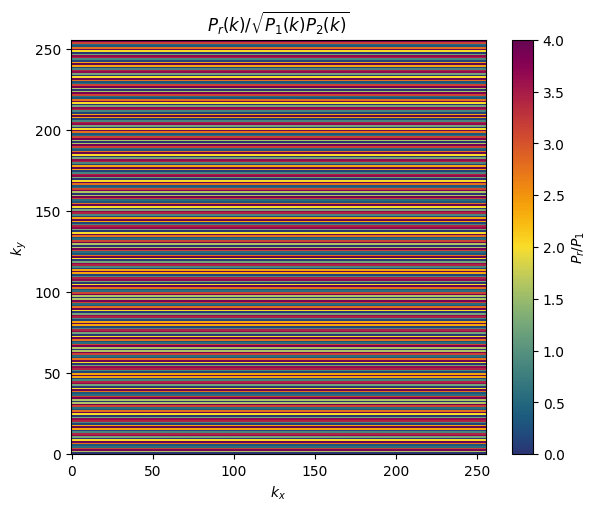

In [12]:
ratio_2d = psr_2d / (np.sqrt(ps1_2d * ps2_2d))

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

im = ax.imshow(
    ratio_2d,
    origin="lower",
    interpolation="none",
    cmap=prd,
    vmin=0, 
    vmax=4
)

ax.set_title(r"$P_r(k) / \sqrt{P_1(k)P_2(k)}$")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")

fig.colorbar(im, ax=ax, label=r"$P_r / P_1$")

plt.show()

What we’re seeing is almost exactly the analytic prediction:

$$
\frac{P_r(\mathbf{k})}{P_1(\mathbf{k})}
=
4\sin^2\left(\frac{\mathbf{k}\cdot\Delta\mathbf{x}}{2}\right).
$$

For your vertical shift, $\Delta\mathbf{x}=(0,\Delta y)$, so

$$
\mathbf{k}\cdot\Delta\mathbf{x}
=
k_y \Delta y.
$$

Hence

$$
\frac{P_r(\mathbf{k})}{P_1(\mathbf{k})}
=
4\sin^2\left(\frac{k_y\Delta y}{2}\right),
$$

which is:

* independent of k_x,
* oscillatory in k_y,
* bounded between 0 and 4.

### Visualising the Fourier Phase Difference

The residual power spectrum tells us that the two fields differ, but it does not directly reveal the origin of those differences. Since the power spectrum depends only on the Fourier amplitudes, any information contained in the Fourier phases is discarded.

To better understand how two fields with identical power spectra differ, we therefore examine the Fourier phase difference,

$$
\Delta\phi(\mathbf{k})
=
\phi_1(\mathbf{k})
-
\phi_2(\mathbf{k}),
$$

which can be computed directly from the Fourier transforms of the two fields.

For the translated-circle example, the Fourier shift theorem predicts

$$
\Delta\phi(\mathbf{k})
=
\mathbf{k}\cdot\Delta\mathbf{x},
$$

corresponding to a simple linear phase ramp across Fourier space. This provides a useful sanity check: if the residual power spectrum is responding to phase differences, then we should be able to see those phase differences directly.

More generally, visualising $\Delta\phi(\mathbf{k})$ allows us to distinguish between simple transformations, such as translations, and more complicated morphological differences that may nevertheless produce identical power spectra.

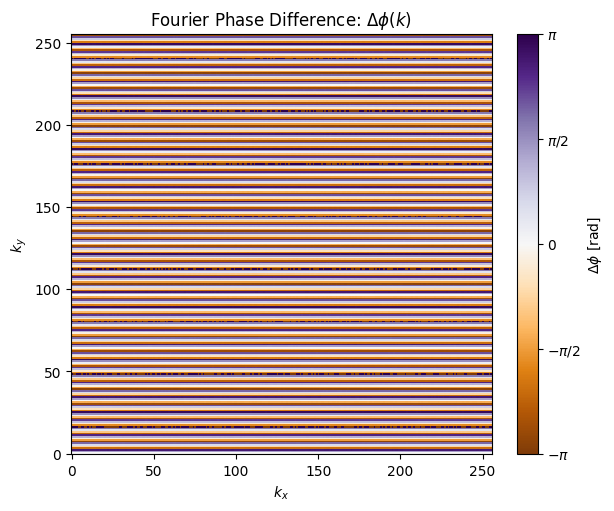

In [13]:
ft1 = np.fft.fftshift(np.fft.fft2(field1))
ft2 = np.fft.fftshift(np.fft.fft2(field2))

phase_diff = np.angle(ft1 * np.conj(ft2))

fig, ax = plt.subplots(
    figsize=(6, 5),
    constrained_layout=True,
)

im = ax.imshow(
    phase_diff,
    origin="lower",
    cmap="PuOr",
    vmin=-np.pi,
    vmax=np.pi,
    interpolation="none",
)

ax.set_title(r"Fourier Phase Difference: $\Delta\phi(k)$")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")

cbar = fig.colorbar(
    im,
    ax=ax,
    label=r"$\Delta\phi$ [rad]",
)

cbar.set_ticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
)

cbar.set_ticklabels(
    [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]
)

plt.show()

## Beyond Simple Translations

The translated-circle example demonstrates the simplest way in which two different fields can have the same power spectrum. A translation changes the Fourier phases, but leaves the Fourier amplitudes unchanged. Therefore the two fields have identical power spectra.

However, this is a fairly special case. The two fields have the same morphology and differ only by a shift. We now want a less trivial example: two fields which have the same power spectrum, but genuinely different real-space structure.

The key idea is the Wiener--Khinchin theorem, which states that the power spectrum and autocorrelation are Fourier transform pairs:

$$
P(\mathbf{k}) = |\tilde f(\mathbf{k})|^2
$$

and

$$
\xi(\mathbf{r}) = \mathcal{F}^{-1}\left[P(\mathbf{k})\right].
$$

Equivalently,

$$
P(\mathbf{k}) = \mathcal{F}\left[\xi(\mathbf{r})\right].
$$

So if two fields have the same autocorrelation, they must also have the same power spectrum.

For a field made of discrete points, the autocorrelation has a simple interpretation: it counts all pairwise separation vectors between points. Therefore, our next goal is to construct two different point distributions which have the same set of pairwise separations, and hence the same autocorrelation.

These two fields will have:

$$
\xi_1(\mathbf{r}) = \xi_2(\mathbf{r}),
$$

and therefore

$$
P_1(\mathbf{k}) = P_2(\mathbf{k}),
$$

but their real-space morphologies will not be related by a simple translation.

This gives us a more interesting test case: the individual power spectra are identical, but the residual field still contains non-trivial structure arising from differences in the Fourier phases.

In [14]:
def autocorrelation_matched_pair(n_a=16, n_b=8, grid_size=256, seed=0):
    """
    Generate two distinct point distributions with identical
    autocorrelations and therefore identical power spectra.

    Uses the construction:

        P = A + B
        Q = A - B

    with |A| * |B| points.
    """
    rng = np.random.default_rng(seed)

    # Keep A widely spaced and B compact so sums/differences are unlikely
    # to collide after rounding onto the integer grid.
    A = rng.integers(64, grid_size - 64, size=(n_a, 2))
    B = rng.integers(-48, 48, size=(n_b, 2))

    P = np.array([a + b for a in A for b in B])
    Q = np.array([a - b for a in A for b in B])

    # Shift both layouts safely into the grid.
    P -= P.min(axis=0)
    Q -= Q.min(axis=0)

    # Add margin so points are comfortably away from boundaries.
    P += 32
    Q += 32

    if P.max() >= grid_size or Q.max() >= grid_size:
        raise ValueError("Point set exceeded grid. Try another seed or smaller B.")

    if len(np.unique(P, axis=0)) != n_a * n_b:
        raise ValueError("P contains duplicate points. Try another seed.")

    if len(np.unique(Q, axis=0)) != n_a * n_b:
        raise ValueError("Q contains duplicate points. Try another seed.")

    return P, Q

In [15]:
def point_field(points, shape=(256, 256)):
    field = np.zeros(shape, dtype=float)
    field[points[:, 1], points[:, 0]] = 1.0
    return field


P, Q = autocorrelation_matched_pair(seed=42)

field1 = point_field(P)
field2 = point_field(Q)
residual = field1 - field2

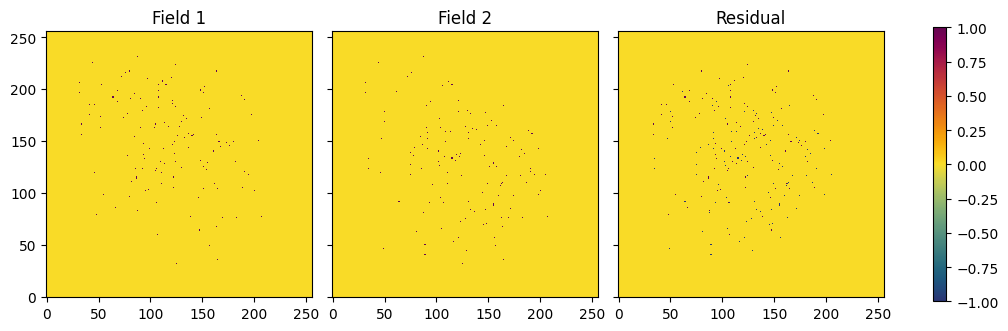

In [16]:
f_list = [field1, field2, residual]

vmin = min(f.min() for f in f_list)
vmax = max(f.max() for f in f_list)

fig, axs = plt.subplots(
    1, 3,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, ps, title in zip(axs, f_list, ["Field 1", "Field 2", "Residual"]):
    im = ax.imshow(
        ps,
        origin="lower",
        cmap=prd,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
    )
    ax.set_title(title)

cbar = fig.colorbar(
    im,
    ax=axs,
    shrink=0.7,
)

plt.show()

In [17]:
k1, p1 = power_spectrum_1d(field1, nbins=64)
k2, p2 = power_spectrum_1d(field2, nbins=64)
kr, pr = power_spectrum_1d(residual, nbins=64)

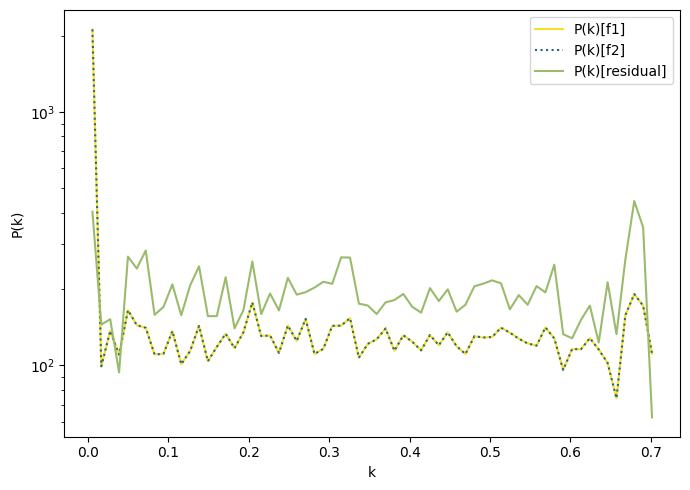

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(k1, p1, color=cmr.pride(0.5), label="P(k)[f1]")
ax.semilogy(k2, p2, color=cmr.pride(0.2), ls=":", label="P(k)[f2]")
ax.semilogy(kr, pr, color=cmr.pride(0.4), label="P(k)[residual]")

plt.legend()

ax.set_ylabel("P(k)")
ax.set_xlabel("k")

plt.tight_layout()
plt.show()

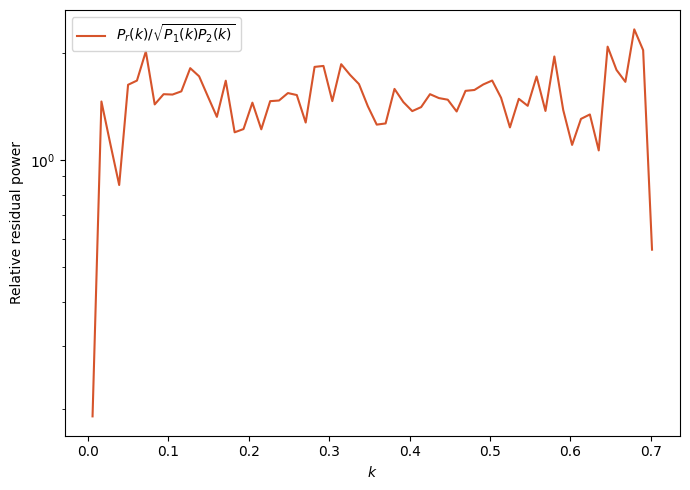

In [19]:
eps = 1e-12

fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(
    kr,
    pr / (np.sqrt(p1 * p2)),
    color=cmr.pride(0.7),
    label=r"$P_r(k)/\sqrt{P_1(k)P_2(k)}$",
)

ax.legend()

ax.set_ylabel("Relative residual power")
ax.set_xlabel(r"$k$")

plt.tight_layout()
plt.show()

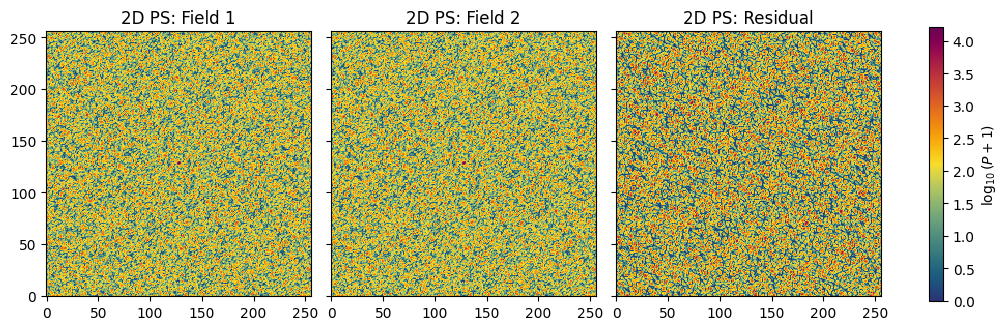

In [20]:
ps1_2d = power_spectrum_2d(field1)
ps2_2d = power_spectrum_2d(field2)
psr_2d = power_spectrum_2d(residual)

ps_list = [
    np.log10(ps1_2d + 1),
    np.log10(ps2_2d + 1),
    np.log10(psr_2d + 1),
]

vmin = min(ps.min() for ps in ps_list)
vmax = max(ps.max() for ps in ps_list)

fig, axs = plt.subplots(
    1, 3,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, ps, title in zip(axs, ps_list, ["2D PS: Field 1", "2D PS: Field 2", "2D PS: Residual"]):
    im = ax.imshow(
        ps,
        origin="lower",
        cmap=prd,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
    )
    ax.set_title(title)

cbar = fig.colorbar(
    im,
    ax=axs,
    shrink=0.7,
    label=r"$\log_{10}(P+1)$",
)

plt.show()

/var/folders/d3/70sqp6554195488sw7mn9_kh0000gn/T/ipykernel_46315/2702373272.py:1: RuntimeWarning: invalid value encountered in divide
  ratio_2d = psr_2d / (np.sqrt(ps1_2d * ps2_2d))


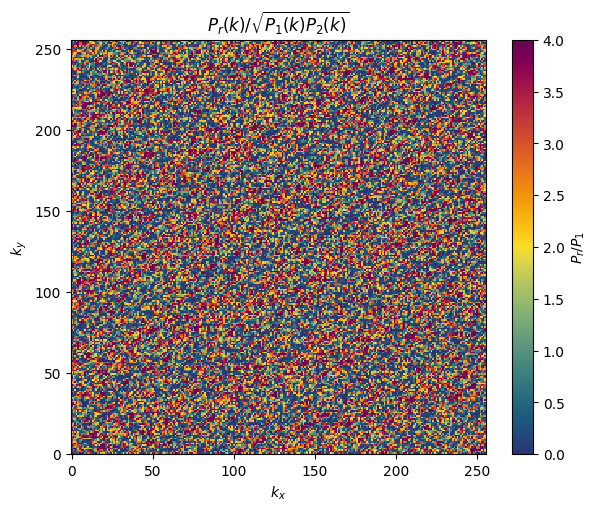

In [21]:
ratio_2d = psr_2d / (np.sqrt(ps1_2d * ps2_2d))

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

im = ax.imshow(
    ratio_2d,
    origin="lower",
    interpolation="none",
    cmap=prd,
    vmin=0, 
    vmax=4
)

ax.set_title(r"$P_r(k) / \sqrt{P_1(k)P_2(k)}$")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")

fig.colorbar(im, ax=ax, label=r"$P_r / P_1$")

plt.show()

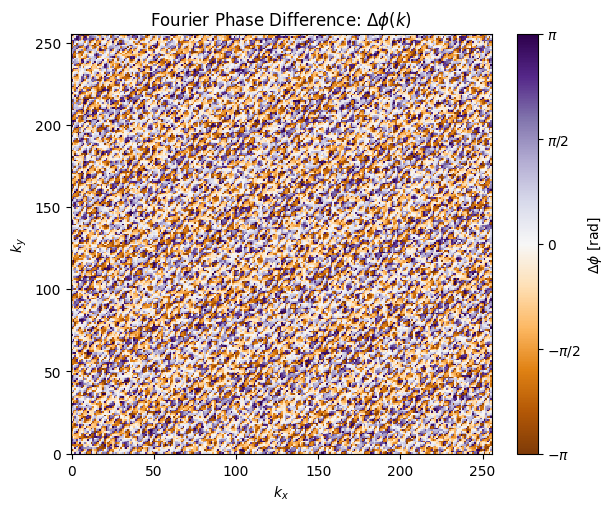

In [22]:
ft1 = np.fft.fftshift(np.fft.fft2(field1))
ft2 = np.fft.fftshift(np.fft.fft2(field2))

phase_diff = np.angle(ft1 * np.conj(ft2))

fig, ax = plt.subplots(
    figsize=(6, 5),
    constrained_layout=True,
)

im = ax.imshow(
    phase_diff,
    origin="lower",
    cmap="PuOr",
    vmin=-np.pi,
    vmax=np.pi,
    interpolation="none",
)

ax.set_title(r"Fourier Phase Difference: $\Delta\phi(k)$")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")

cbar = fig.colorbar(
    im,
    ax=ax,
    label=r"$\Delta\phi$ [rad]",
)

cbar.set_ticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
)

cbar.set_ticklabels(
    [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]
)

plt.show()

## From Matched Autocorrelations to Gaussian Random Fields

The previous example demonstrated that two point distributions can possess identical autocorrelations, and therefore identical power spectra, while exhibiting noticeably different morphologies. This follows directly from the Wiener--Khinchin theorem, which states that the power spectrum and autocorrelation are Fourier transform pairs:

$$
P(\mathbf{k})
=
\mathcal{F}\!\left[\xi(\mathbf{r})\right].
$$

In that example, the two fields were carefully constructed so that their autocorrelations matched exactly. While this provides a useful illustration of the information lost when reducing a field to its power spectrum, it represents a rather special situation.

The next logical step is to generate two independent Gaussian random field (GRF) realisations from a common input power spectrum. Unlike the previous examples, the two fields are not constructed to have identical Fourier amplitudes. Instead, they are independent draws from the same statistical ensemble and therefore share the same underlying power spectrum only in expectation.

The Fourier transform of a field may be written as

$$
\tilde f(\mathbf{k})
=
A(\mathbf{k})
e^{i\phi(\mathbf{k})},
$$

where the power spectrum is

$$
P(\mathbf{k})
=
|\tilde f(\mathbf{k})|^2
=
A^2(\mathbf{k}).
$$

Independent realisations differ in both their Fourier amplitudes and phases, producing different real-space morphologies despite being generated from the same statistical model.

This example therefore moves beyond the deliberately constructed cases considered previously. Rather than asking whether two fields with identical power spectra can look different, we now ask how much variation naturally arises between fields that share the same underlying statistical description. By comparing the two realisations, their residual field, and their power spectra, we can explore the relative roles of amplitude fluctuations and phase differences in shaping the observed structure.

In [23]:
def powerlaw_ps_2d(shape=(256, 256), alpha=3.0, k0=1.0):
    """
    Construct a simple isotropic power-law 2D power spectrum.

    P(k) ∝ (k + k0)^(-alpha)
    """
    ny, nx = shape

    kx = np.fft.fftfreq(nx)
    ky = np.fft.fftfreq(ny)

    kx_grid, ky_grid = np.meshgrid(kx, ky)
    k = np.sqrt(kx_grid**2 + ky_grid**2)

    ps = (k + k0 / max(shape)) ** (-alpha)
    ps[0, 0] = 0.0

    return ps


def grf_from_power_spectrum(ps, seed=0):
    """
    Generate a real Gaussian random field with a prescribed 2D power spectrum.
    """
    rng = np.random.default_rng(seed)

    white_noise = rng.normal(size=ps.shape)
    white_ft = np.fft.fft2(white_noise)

    amplitude = np.sqrt(ps)

    field = np.fft.ifft2(white_ft * amplitude).real

    return field

In [24]:
ps_target = powerlaw_ps_2d(
    shape=(256, 256),
    alpha=3.0,
)

field1 = grf_from_power_spectrum(ps_target, seed=42)
field2 = grf_from_power_spectrum(ps_target, seed=69)

residual = field1 - field2

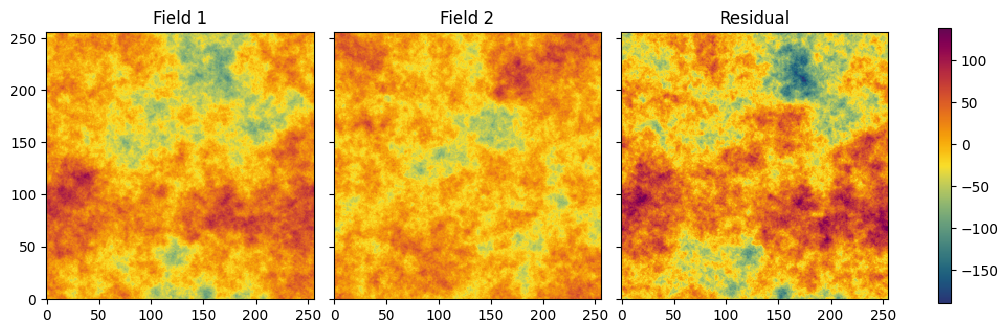

In [25]:
f_list = [field1, field2, residual]

vmin = min(f.min() for f in f_list)
vmax = max(f.max() for f in f_list)

fig, axs = plt.subplots(
    1, 3,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, ps, title in zip(axs, f_list, ["Field 1", "Field 2", "Residual"]):
    im = ax.imshow(
        ps,
        origin="lower",
        cmap=prd,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
    )
    ax.set_title(title)

cbar = fig.colorbar(
    im,
    ax=axs,
    shrink=0.7,
)

plt.show()

In [26]:
k1, p1 = power_spectrum_1d(field1, nbins=64)
k2, p2 = power_spectrum_1d(field2, nbins=64)
kr, pr = power_spectrum_1d(residual, nbins=64)

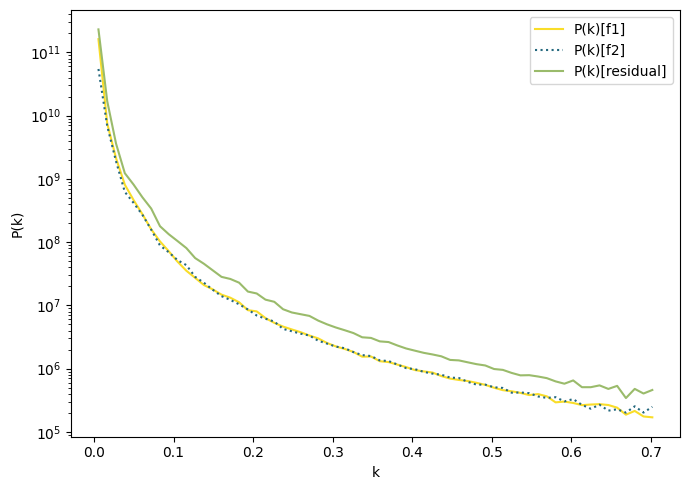

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(k1, p1, color=cmr.pride(0.5), label="P(k)[f1]")
ax.semilogy(k2, p2, color=cmr.pride(0.2), ls=":", label="P(k)[f2]")
ax.semilogy(kr, pr, color=cmr.pride(0.4), label="P(k)[residual]")

plt.legend()

ax.set_ylabel("P(k)")
ax.set_xlabel("k")

plt.tight_layout()
plt.show()

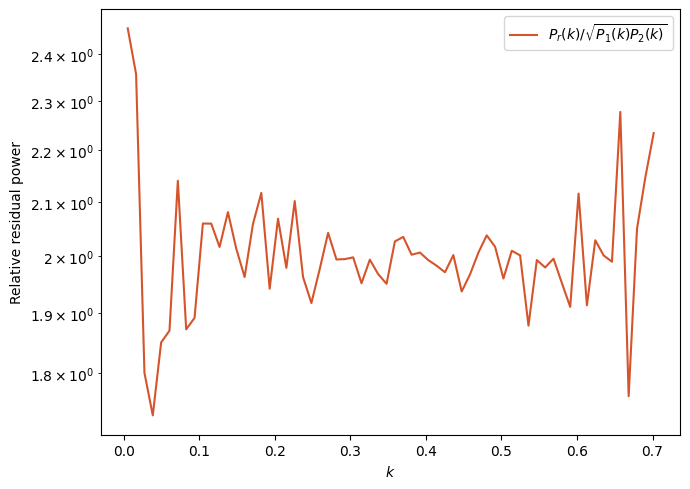

In [28]:
eps = 1e-12

fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(
    kr,
    pr / (np.sqrt(p1 * p2)),
    color=cmr.pride(0.7),
    label=r"$P_r(k)/\sqrt{P_1(k)P_2(k)}$",
)

ax.legend()

ax.set_ylabel("Relative residual power")
ax.set_xlabel(r"$k$")

plt.tight_layout()
plt.show()

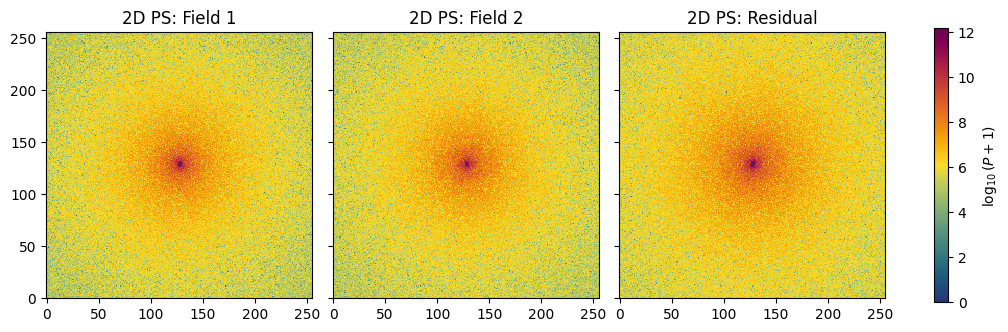

In [29]:
ps1_2d = power_spectrum_2d(field1)
ps2_2d = power_spectrum_2d(field2)
psr_2d = power_spectrum_2d(residual)

ps_list = [
    np.log10(ps1_2d + 1),
    np.log10(ps2_2d + 1),
    np.log10(psr_2d + 1),
]

vmin = min(ps.min() for ps in ps_list)
vmax = max(ps.max() for ps in ps_list)

fig, axs = plt.subplots(
    1, 3,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, ps, title in zip(axs, ps_list, ["2D PS: Field 1", "2D PS: Field 2", "2D PS: Residual"]):
    im = ax.imshow(
        ps,
        origin="lower",
        cmap=prd,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
    )
    ax.set_title(title)

cbar = fig.colorbar(
    im,
    ax=axs,
    shrink=0.7,
    label=r"$\log_{10}(P+1)$",
)

plt.show()

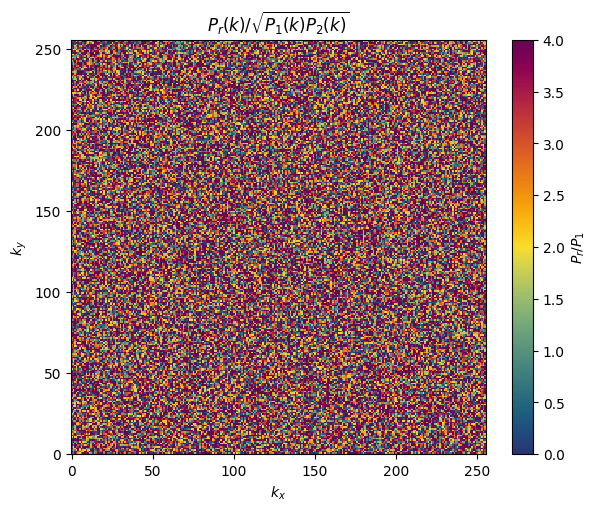

In [30]:
ratio_2d = psr_2d / (np.sqrt(ps1_2d * ps2_2d))

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

im = ax.imshow(
    ratio_2d,
    origin="lower",
    interpolation="none",
    cmap=prd,
    vmin=0, 
    vmax=4
)

ax.set_title(r"$P_r(k) / \sqrt{P_1(k)P_2(k)}$")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")

fig.colorbar(im, ax=ax, label=r"$P_r / P_1$")

plt.show()

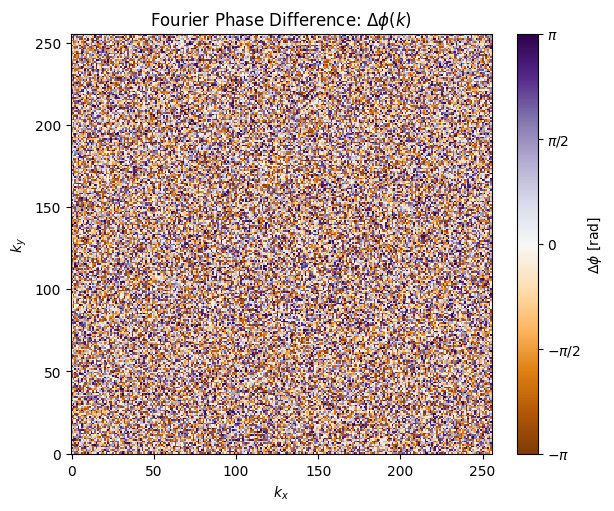

In [31]:
ft1 = np.fft.fftshift(np.fft.fft2(field1))
ft2 = np.fft.fftshift(np.fft.fft2(field2))

phase_diff = np.angle(ft1 * np.conj(ft2))

fig, ax = plt.subplots(
    figsize=(6, 5),
    constrained_layout=True,
)

im = ax.imshow(
    phase_diff,
    origin="lower",
    cmap="PuOr",
    vmin=-np.pi,
    vmax=np.pi,
    interpolation="none",
)

ax.set_title(r"Fourier Phase Difference: $\Delta\phi(k)$")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")

cbar = fig.colorbar(
    im,
    ax=ax,
    label=r"$\Delta\phi$ [rad]",
)

cbar.set_ticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
)

cbar.set_ticklabels(
    [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]
)

plt.show()

## What Does the Residual Power Spectrum Measure?

We have now seen three related examples:

1. Two fields related by a translation.
2. Two different point distributions with identical autocorrelations.
3. Two Gaussian random fields drawn from the same underlying power spectrum.

In all cases, the residual field is

$$
r(\mathbf{x}) = f_1(\mathbf{x}) - f_2(\mathbf{x}).
$$

Taking the Fourier transform,

$$
\tilde r(\mathbf{k})
=
\tilde f_1(\mathbf{k})
-
\tilde f_2(\mathbf{k}).
$$

The residual power spectrum is therefore

$$
P_r(\mathbf{k})
=
|\tilde r(\mathbf{k})|^2
=
|\tilde f_1(\mathbf{k})-\tilde f_2(\mathbf{k})|^2.
$$

Expanding this gives

$$
P_r(\mathbf{k})
=
|\tilde f_1(\mathbf{k})|^2
+
|\tilde f_2(\mathbf{k})|^2
-
2\,\mathrm{Re}
\left[
\tilde f_1(\mathbf{k})
\tilde f_2^*(\mathbf{k})
\right].
$$

Using

$$
P_1(\mathbf{k}) = |\tilde f_1(\mathbf{k})|^2
$$

and

$$
P_2(\mathbf{k}) = |\tilde f_2(\mathbf{k})|^2,
$$

we obtain

$$
P_r(\mathbf{k})
=
P_1(\mathbf{k})
+
P_2(\mathbf{k})
-
2\,\mathrm{Re}
\left[
\tilde f_1(\mathbf{k})
\tilde f_2^*(\mathbf{k})
\right].
$$

The final term is the real part of the cross-spectrum. This term contains the relative phase information between the two fields. Therefore, the residual power spectrum is not determined by the two auto-power spectra alone; it also depends on how the Fourier modes of the two fields are aligned in phase.

### Identical Power Spectra

If the two fields have identical power spectra, we can write

$$
\tilde f_1(\mathbf{k})
=
A(\mathbf{k})e^{i\phi_1(\mathbf{k})},
$$

and

$$
\tilde f_2(\mathbf{k})
=
A(\mathbf{k})e^{i\phi_2(\mathbf{k})}.
$$

Then

$$
P_1(\mathbf{k}) = P_2(\mathbf{k}) = A^2(\mathbf{k}) = P(\mathbf{k}),
$$

and

$$
P_r(\mathbf{k})
=
4P(\mathbf{k})
\sin^2
\left[
\frac{\Delta\phi(\mathbf{k})}{2}
\right],
$$

where

$$
\Delta\phi(\mathbf{k})
=
\phi_1(\mathbf{k})-\phi_2(\mathbf{k}).
$$

This explains why two fields can have identical power spectra while still producing a non-zero residual power spectrum. The residual is sensitive to phase differences, while the individual power spectra are not.

### Independent Realisations from the Same Ensemble

For two independent Gaussian random fields drawn from the same statistical ensemble, the fields are not expected to have identical power spectra mode-by-mode. Instead, they share the same ensemble-averaged power spectrum:

$$
\langle P_1(\mathbf{k}) \rangle
=
\langle P_2(\mathbf{k}) \rangle
=
P_{\rm input}(\mathbf{k}).
$$

The residual power spectrum is still

$$
P_r(\mathbf{k})
=
P_1(\mathbf{k})
+
P_2(\mathbf{k})
-
2\,\mathrm{Re}
\left[
\tilde f_1(\mathbf{k})
\tilde f_2^*(\mathbf{k})
\right].
$$

However, because the two realisations are statistically independent, their cross-spectrum averages to zero:

$$
\left\langle
\tilde f_1(\mathbf{k})
\tilde f_2^*(\mathbf{k})
\right\rangle
=
0.
$$

Therefore,

$$
\langle P_r(\mathbf{k}) \rangle
=
\langle P_1(\mathbf{k}) \rangle
+
\langle P_2(\mathbf{k}) \rangle.
$$

Since both fields are drawn from the same input power spectrum,

$$
\langle P_r(\mathbf{k}) \rangle
=
2P_{\rm input}(\mathbf{k}).
$$

So, for independent realisations from the same ensemble, the residual field is expected to have approximately twice the power of either individual field:

$$
\frac{\langle P_r(\mathbf{k}) \rangle}
{\langle P_1(\mathbf{k}) \rangle}
\approx
2.
$$

This factor of two has a different origin from the translated-field example. For a translation, it arose from angularly averaging a coherent phase ramp. For independent Gaussian random fields, it arises because the fields are statistically uncorrelated.

### Interpretation

The residual power spectrum answers the question: How much Fourier-space power is present in the difference between two fields?

It is therefore a useful diagnostic for detecting that two fields differ. However, it does not fully describe the nature of the difference. The missing information is contained in the cross-spectrum, or equivalently in the relative Fourier phases.

The examples above show that:

- identical power spectra do not imply identical real-space structure;
- residual power spectra are sensitive to phase differences;
- independent realisations from the same ensemble naturally produce residuals with approximately twice the input power;
- visualising phase differences or cross-spectra can provide more direct insight into how two fields differ.

The power spectrum is therefore an incomplete description of morphology. It captures the distribution of variance across spatial scales, but discards the phase information that determines where structures actually appear.

## Conclusions

These examples demonstrate several important points:

- The power spectrum depends only on Fourier amplitudes and is insensitive to Fourier phases.
- Fields with identical power spectra can possess very different morphologies.
- Residual power spectra are sensitive to phase differences between fields.
- For simple transformations, such as translations, the residual power spectrum can reveal the nature of the difference.
- In more general cases, the residual power spectrum indicates that differences exist, but does not uniquely describe them.
- The missing information resides in the Fourier phases and cross-spectrum.

The power spectrum is therefore an incomplete description of morphology. It characterises how variance is distributed across spatial scales, but not where structures are located in real space.